In [18]:
import pandas as pd
df=pd.read_csv('/workspaces/BlizzardX/Data/cleaned_data.csv')

/tmp/ipykernel_782/4145723783.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Missing_Samples', y='ID', data=missing_data, palette='Blues_d')


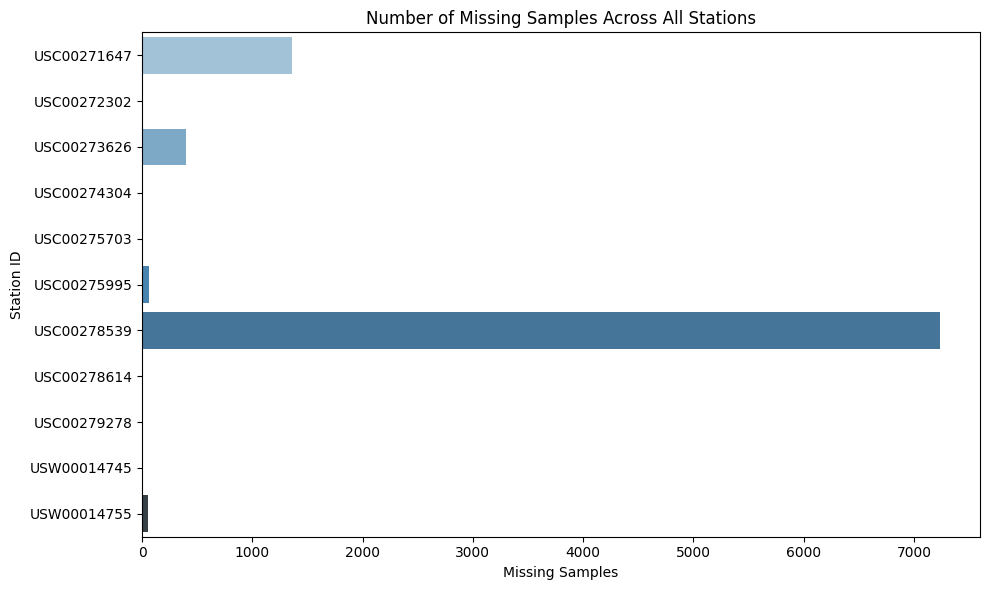

/tmp/ipykernel_782/4145723783.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentage_Missing', y='ID', data=missing_data, palette='Reds_d')


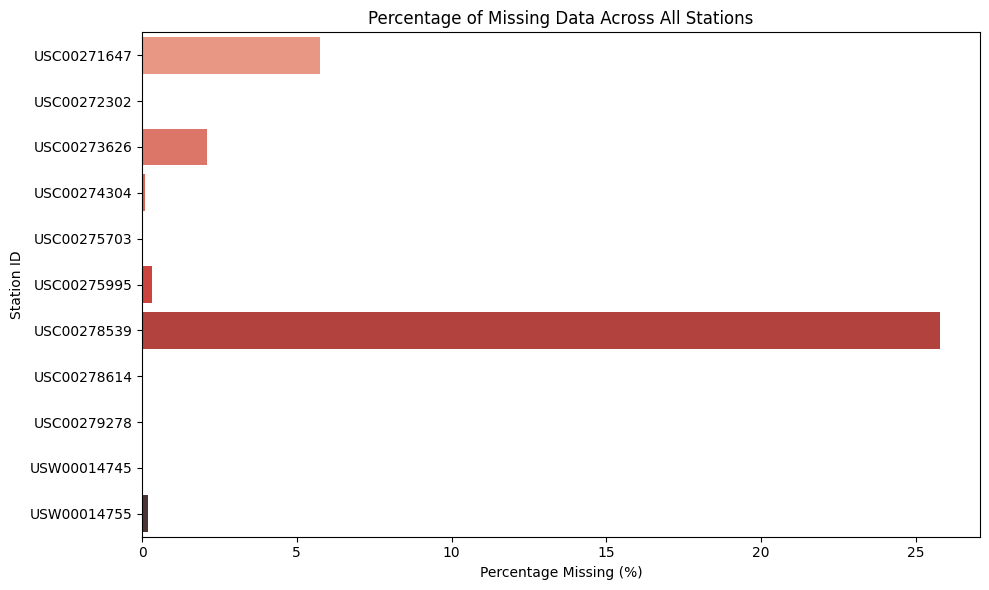

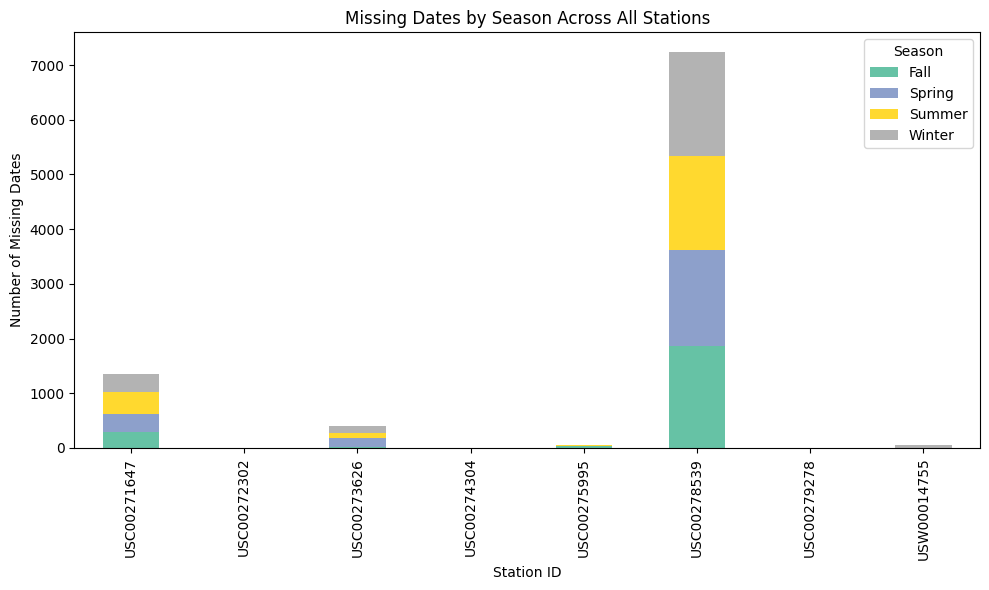

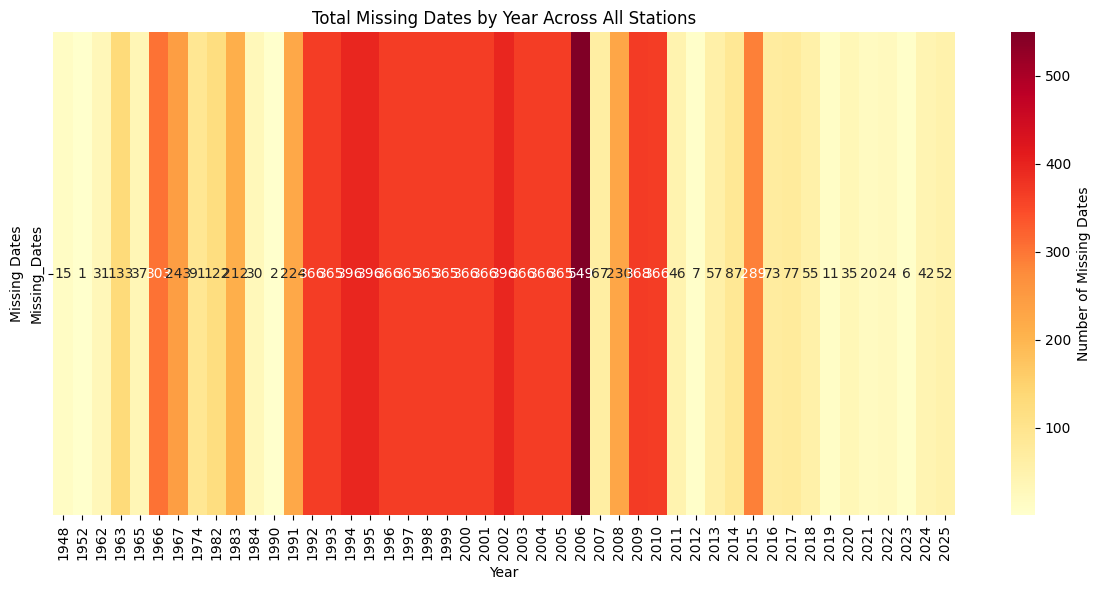

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Ensure the DATE column is in datetime format
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')

# Step 1: Define the station date ranges by calculating min and max dates from the data
station_dates = df.groupby('ID').agg(
    Start_Date=('DATE', 'min'),   # The earliest date for each station
    End_Date=('DATE', 'max'),     # The latest date for each station
    Start_Year=('DATE', lambda x: x.min().year),  # The year of the start date
    End_Year=('DATE', lambda x: x.max().year)     # The year of the end date
).reset_index()

# Step 2: Calculate expected samples per station
station_dates['Expected_Samples'] = (station_dates['End_Date'] - station_dates['Start_Date']).dt.days + 1

# Step 3: Calculate actual samples per station
actual_samples = df.groupby('ID').size().reset_index(name='Actual_Samples')

# Step 4: Merge expected and actual samples
missing_data = pd.merge(station_dates, actual_samples, on='ID', how='left')

# Step 5: Calculate missing samples and percentage
missing_data['Missing_Samples'] = missing_data['Expected_Samples'] - missing_data['Actual_Samples']
missing_data['Percentage_Missing'] = (missing_data['Missing_Samples'] / missing_data['Expected_Samples']) * 100

# Step 6: Visualization 1 - Bar Plot for Missing Samples Across All Stations
plt.figure(figsize=(10, 6))
sns.barplot(x='Missing_Samples', y='ID', data=missing_data, palette='Blues_d')
plt.title('Number of Missing Samples Across All Stations')
plt.xlabel('Missing Samples')
plt.ylabel('Station ID')
plt.tight_layout()
plt.show()

# Step 7: Visualization 2 - Bar Plot for Percentage of Missing Data Across All Stations
plt.figure(figsize=(10, 6))
sns.barplot(x='Percentage_Missing', y='ID', data=missing_data, palette='Reds_d')
plt.title('Percentage of Missing Data Across All Stations')
plt.xlabel('Percentage Missing (%)')
plt.ylabel('Station ID')
plt.tight_layout()
plt.show()

# Step 8: Function to find missing dates for a station
def find_missing_dates(station_data, start_date, end_date):
    expected_dates = pd.date_range(start=start_date, end=end_date, freq='D')
    actual_dates = station_data['DATE'].dropna().unique()
    actual_dates = pd.to_datetime(actual_dates)
    missing_dates = [date for date in expected_dates if date not in actual_dates]
    return missing_dates

# Step 9: Collect missing dates for all stations
missing_dates_dict = {}
for _, row in missing_data.iterrows():
    station_id = row['ID']
    start_date = row['Start_Date']
    end_date = row['End_Date']
    
    station_data = df[df['ID'] == station_id].copy()
    missing_dates = find_missing_dates(station_data, start_date, end_date)
    missing_dates_dict[station_id] = missing_dates

# Step 10: Aggregate missing dates by season and station for Visualization 3
seasonal_missing = pd.DataFrame()
for station_id, missing_dates in missing_dates_dict.items():
    if missing_dates:
        missing_df = pd.DataFrame({'Missing_Date': missing_dates, 'Station_ID': station_id})
        missing_df['Season'] = missing_df['Missing_Date'].dt.month.map(
            lambda x: 'Winter' if x in [12, 1, 2] else
                      'Spring' if x in [3, 4, 5] else
                      'Summer' if x in [6, 7, 8] else
                      'Fall'
        )
        seasonal_missing = pd.concat([seasonal_missing, missing_df], ignore_index=True)

# Create a pivot table for the stacked bar plot
seasonal_pivot = seasonal_missing.pivot_table(index='Station_ID', columns='Season', values='Missing_Date', 
                                              aggfunc='size', fill_value=0)

# Visualization 3 - Stacked Bar Plot for Missing Dates by Season Across All Stations
seasonal_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Missing Dates by Season Across All Stations')
plt.xlabel('Station ID')
plt.ylabel('Number of Missing Dates')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

# Step 11: Aggregate missing dates by year for Visualization 4
all_missing_dates = pd.DataFrame()
for station_id, missing_dates in missing_dates_dict.items():
    if missing_dates:
        missing_df = pd.DataFrame({'Missing_Date': missing_dates, 'Station_ID': station_id})
        missing_df['Year'] = missing_df['Missing_Date'].dt.year
        all_missing_dates = pd.concat([all_missing_dates, missing_df], ignore_index=True)

# Create a pivot table for the heatmap (aggregate by year across all stations)
yearly_missing = all_missing_dates.groupby('Year').size().reset_index(name='Missing_Dates')

# Visualization 4 - Heatmap for Total Missing Dates by Year Across All Stations
plt.figure(figsize=(12, 6))
sns.heatmap(yearly_missing.set_index('Year').T, cmap='YlOrRd', annot=True, fmt='d', cbar_kws={'label': 'Number of Missing Dates'})
plt.title('Total Missing Dates by Year Across All Stations')
plt.xlabel('Year')
plt.ylabel('Missing Dates')
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

# Assuming df is your DataFrame with the data
df['DATE'] = pd.to_datetime(df['DATE'])  # Ensure DATE is a datetime type

# Group by Station_ID and calculate the start date, end date, and start year, end year
station_dates = df.groupby('ID').agg(
    Start_Date=('DATE', 'min'),   # The earliest date for each station
    End_Date=('DATE', 'max'),     # The latest date for each station
    Start_Year=('DATE', lambda x: x.min().year),  # The year of the start date
    End_Year=('DATE', lambda x: x.max().year)     # The year of the end date
).reset_index()

# Display the result
print(station_dates)


             ID Start_Date   End_Date  Start_Year  End_Year
0   USC00271647 1960-07-01 2025-03-31        1960      2025
1   USC00272302 2008-07-01 2025-04-01        2008      2025
2   USC00273626 1973-08-01 2025-03-07        1973      2025
3   USC00274304 2011-04-29 2025-04-01        2011      2025
4   USC00275703 2014-09-01 2025-04-01        2014      2025
5   USC00275995 1974-03-01 2025-04-01        1974      2025
6   USC00278539 1948-06-01 2025-04-01        1948      2025
7   USC00278614 2000-11-01 2025-04-01        2000      2025
8   USC00279278 2006-12-01 2025-04-01        2006      2025
9   USW00014745 1939-04-01 2025-03-31        1939      2025
10  USW00014755 1948-01-01 2025-04-01        1948      2025


In [2]:
import sys
sys.path.append('/workspaces/BlizzardX')

In [3]:
from src.Model.feature_engineering import FeatureEngineering , ColdEventDetector
fe=FeatureEngineering(df)
ce =ColdEventDetector(fe.apply_all_features())

In [4]:
df=ce.apply_cold_event_detection()

In [7]:
df[df['Cold_Event'] == 1]['Cold_Event'].count(),df[df['Cold_Event'] == 0]['Cold_Event'].count()

(np.int64(21250), np.int64(76131))